# Structural Backfire Analysis

For each run, we:
1. Identify the targeted node from the step-20000 GEXF (`target=True`)
2. Compute its structural position: in-degree, betweenness centrality, local clustering coefficient, PageRank, eigenvector centrality
3. Measure the backfire effect: Δopposite − Δtarget post-share (late window minus pre-intervention baseline)
4. Scatter-plot each structural metric against backfire magnitude with Spearman correlation

Runs with no valid target (empty moderate-influencer pool) are silently excluded.

**Note on eigenvector centrality:** computed as the left eigenvector of the directed adjacency matrix (hub score). Falls back to NaN if power iteration fails to converge.

In [51]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import xml.etree.ElementTree as ET
from scipy import stats

RESULTS_DIR = "./results"
BINS = ["bin_0", "bin_1", "bin_2", "bin_3", "bin_4"]

# step window just before intervention = baseline; end of simulation = outcome
PRE_RANGE  = (19000, 20000)
POST_RANGE = (39000, 40000)

# Seed filter: set to a list of ints to analyse only those seeds, e.g. [0, 1, 5]
# Set to None to include all seeds.
#SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
SEEDS = [0, 1, 2, 3, 4]

In [52]:
# ---------------------------------------------------------------------------
# GEXF parsing: return (DiGraph, target_node_id, node_opinions)
# node_opinions: dict {node_id: float opinion at this snapshot}
# ---------------------------------------------------------------------------
def parse_gexf_for_target(fpath):
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]

        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')

        G = nx.DiGraph()
        target_node = None
        node_opinions = {}

        for node in root.findall(".//node"):
            nid = node.get('id')
            G.add_node(nid)
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                if title == 'target' and av.get('value', '').lower() == 'true':
                    target_node = nid
                if title == 'opinion':
                    try:
                        node_opinions[nid] = float(av.get('value'))
                    except (TypeError, ValueError):
                        pass

        for edge in root.findall(".//edge"):
            G.add_edge(edge.get('source'), edge.get('target'))

        return G, target_node, node_opinions
    except Exception as e:
        print(f"  [WARN] GEXF parse failed ({fpath}): {e}")
        return None, None, {}


def get_target_structural_metrics(G, target_id):
    """Node-level structural indices for the targeted agent."""
    if G is None or target_id is None or target_id not in G:
        return {}

    in_degree = G.in_degree(target_id)

    bc_all = nx.betweenness_centrality(G, normalized=True)
    betweenness = bc_all.get(target_id, np.nan)

    G_und = G.to_undirected()
    clustering = nx.clustering(G_und, target_id)

    pr_all = nx.pagerank(G, alpha=0.85, max_iter=200)
    pagerank = pr_all.get(target_id, np.nan)

    try:
        ec_all = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
        eigenvector = ec_all.get(target_id, np.nan)
    except nx.PowerIterationFailedConvergence:
        eigenvector = np.nan

    return {
        'in_degree':   in_degree,
        'betweenness': betweenness,
        'clustering':  clustering,
        'pagerank':    pagerank,
        'eigenvector': eigenvector,
    }


def get_follower_opinion_metrics(G, target_id, node_opinions, target_sign):
    """
    Opinion-based homophily metrics for the target's follower (in-neighbor) set.

    follower_mean_opinion   : signed mean opinion of followers
    follower_opinion_std    : std of follower opinions (echo-chamber depth)
    follower_homophily_frac : fraction of followers with same sign as target
    follower_dir_alignment  : fraction of followers aligned with manipulation direction
                              (sign matches target_sign) — key predictor for backfire
    target_opinion          : target node's own opinion at the snapshot
    """
    if G is None or target_id is None or target_id not in G:
        return {}

    target_op = node_opinions.get(target_id, np.nan)

    # in-neighbors are the nodes whose edges point TO the target (i.e. followers)
    followers = list(G.predecessors(target_id))
    follower_ops = np.array([node_opinions[f] for f in followers if f in node_opinions])

    if len(follower_ops) == 0:
        return {
            'target_opinion':          target_op,
            'follower_mean_opinion':   np.nan,
            'follower_opinion_std':    np.nan,
            'follower_homophily_frac': np.nan,
            'follower_dir_alignment':  np.nan,
        }

    same_sign_as_target = np.sign(follower_ops) == np.sign(target_op) if not np.isnan(target_op) else np.nan
    same_sign_as_dir    = np.sign(follower_ops) == np.sign(target_sign)

    return {
        'target_opinion':          target_op,
        'follower_mean_opinion':   float(np.mean(follower_ops)),
        'follower_opinion_std':    float(np.std(follower_ops)),
        'follower_homophily_frac': float(np.mean(same_sign_as_target)) if not np.isnan(target_op) else np.nan,
        'follower_dir_alignment':  float(np.mean(same_sign_as_dir)),
    }

In [53]:
# ---------------------------------------------------------------------------
# Backfire effect per run
# backfire_effect = (Δopposite_share) − (Δtarget_share)
# Positive value  => opposite side grew more = backfire
# ---------------------------------------------------------------------------
def compute_backfire_effect(run_dir, target_sign, pre_range, post_range):
    post_dir = os.path.join(run_dir, "posts")
    files = glob.glob(os.path.join(post_dir, "post_result_*.csv"))
    if not files:
        return np.nan

    dfs = []
    for f in files:
        try:
            dfs.append(pd.read_csv(f))
        except Exception:
            pass
    if not dfs:
        return np.nan

    df = pd.concat(dfs, ignore_index=True).sort_values('step')

    # relative bin assignment
    if target_sign > 0:
        target_bins   = ["bin_3", "bin_4"]
        opposite_bins = ["bin_0", "bin_1"]
    else:
        target_bins   = ["bin_0", "bin_1"]
        opposite_bins = ["bin_3", "bin_4"]

    def mean_share(df, bins, step_range):
        mask = (df['step'] >= step_range[0]) & (df['step'] <= step_range[1])
        sub = df[mask].copy()
        if sub.empty:
            return np.nan
        total = sub[BINS].sum(axis=1).replace(0, np.nan)
        return (sub[bins].sum(axis=1) / total).mean()

    target_pre    = mean_share(df, target_bins,   pre_range)
    target_post   = mean_share(df, target_bins,   post_range)
    opposite_pre  = mean_share(df, opposite_bins, pre_range)
    opposite_post = mean_share(df, opposite_bins, post_range)

    delta_target   = target_post   - target_pre
    delta_opposite = opposite_post - opposite_pre

    return delta_opposite - delta_target

In [54]:
# ---------------------------------------------------------------------------
# Main data collection loop
# ---------------------------------------------------------------------------
records = []
run_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, "run_*")))
print(f"Found {len(run_dirs)} run directories.")

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m:
        continue
    seed        = int(m.group(1))
    target_sign = float(m.group(2))

    if SEEDS is not None and seed not in SEEDS:
        continue

    gexf_files = glob.glob(os.path.join(run_dir, "GEXF", "*", "step_20000.gexf"))
    if not gexf_files:
        print(f"  [SKIP] {dirname}: no step_20000 GEXF")
        continue

    print(f"Processing {dirname} ...", end=" ")
    G, target_id, node_opinions = parse_gexf_for_target(gexf_files[0])
    if target_id is None:
        print("no target node (pool was empty, run excluded)")
        continue

    struct   = get_target_structural_metrics(G, target_id)
    homophily = get_follower_opinion_metrics(G, target_id, node_opinions, target_sign)
    backfire = compute_backfire_effect(run_dir, target_sign, PRE_RANGE, POST_RANGE)

    records.append({
        'run_id':          dirname,
        'seed':            seed,
        'target_sign':     target_sign,
        'target_id':       target_id,
        'backfire_effect': backfire,
        **struct,
        **homophily,
    })
    print(f"target={target_id}, dir_align={homophily.get('follower_dir_alignment', float('nan')):.3f}, "
          f"homophily={homophily.get('follower_homophily_frac', float('nan')):.3f}, "
          f"backfire={backfire:.4f}")

df = pd.DataFrame(records)
print(f"\nCollected {len(df)} valid runs.")
print(df[['seed', 'target_sign', 'in_degree', 'betweenness', 'clustering',
          'pagerank', 'eigenvector',
          'target_opinion', 'follower_mean_opinion', 'follower_opinion_std',
          'follower_homophily_frac', 'follower_dir_alignment',
          'backfire_effect']].describe())

Found 200 run directories.
Processing run_0_dir_-1.0 ... target=10, dir_align=0.556, homophily=0.556, backfire=0.0980
Processing run_0_dir_1.0 ... target=10, dir_align=0.444, homophily=0.444, backfire=0.1428
Processing run_1_dir_-1.0 ... target=10, dir_align=0.667, homophily=0.667, backfire=0.6311
Processing run_1_dir_1.0 ... target=10, dir_align=0.333, homophily=0.667, backfire=-0.6089
Processing run_2_dir_-1.0 ... target=5, dir_align=0.250, homophily=0.750, backfire=-0.3402
Processing run_2_dir_1.0 ... target=5, dir_align=0.750, homophily=0.750, backfire=0.2997
Processing run_3_dir_-1.0 ... target=43, dir_align=0.511, homophily=0.489, backfire=-0.0341
Processing run_3_dir_1.0 ... target=43, dir_align=0.489, homophily=0.489, backfire=0.0534
Processing run_4_dir_-1.0 ... target=9, dir_align=0.574, homophily=0.574, backfire=0.3632
Processing run_4_dir_1.0 ... target=9, dir_align=0.426, homophily=0.574, backfire=-0.2481

Collected 10 valid runs.
            seed  target_sign   in_degree 

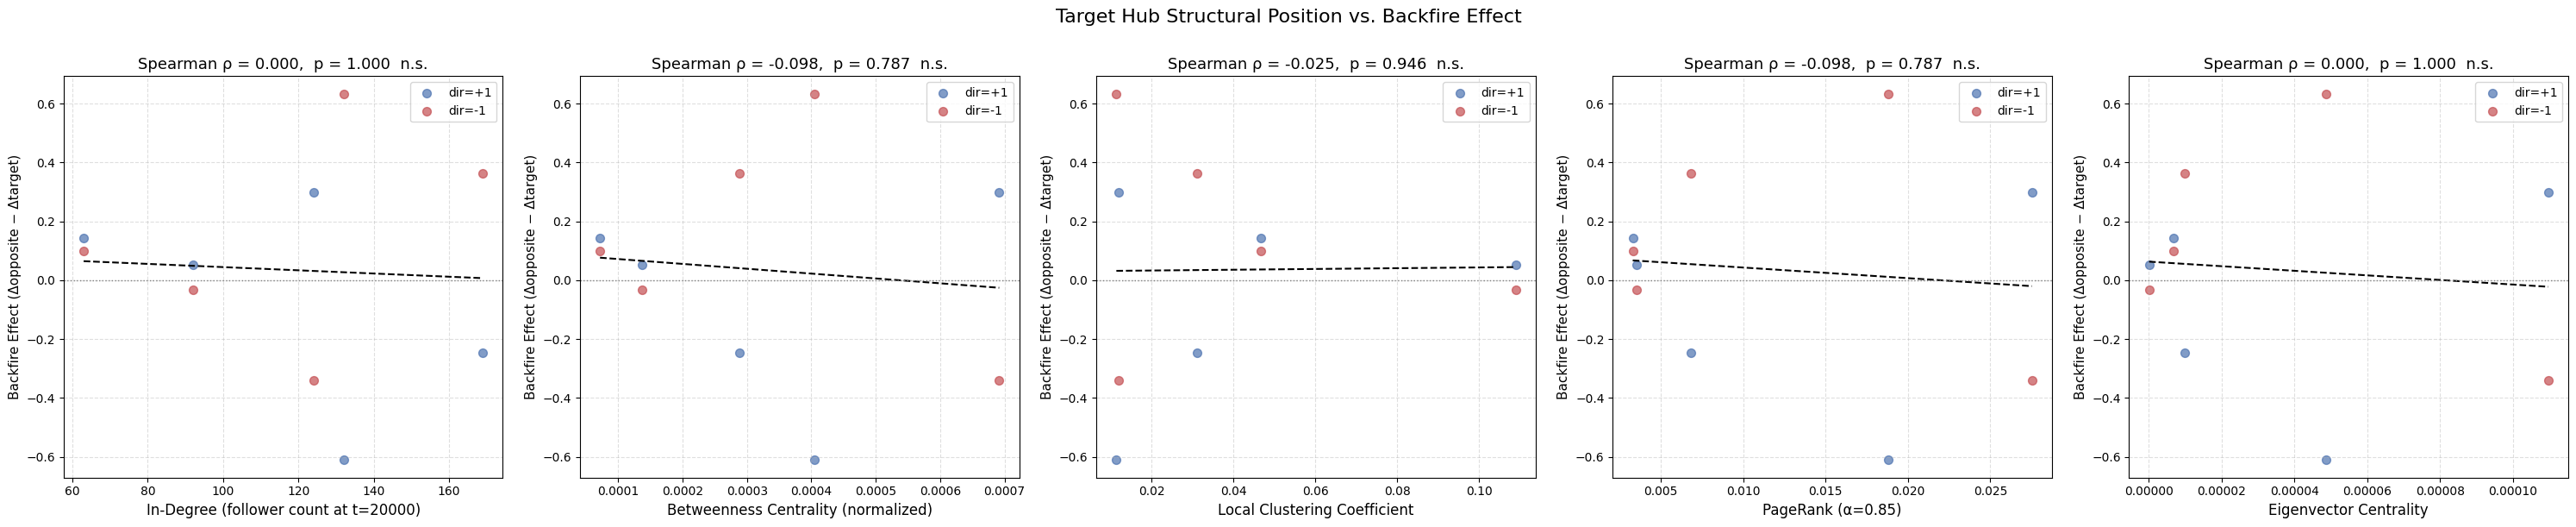

Figure saved to results/summary/structural_backfire.png


In [55]:
# ---------------------------------------------------------------------------
# Scatter plots: structural metric (x) vs backfire effect (y)
# One panel per metric; Spearman r used (distribution-free, robust to outliers)
# ---------------------------------------------------------------------------
STRUCTURAL_METRICS = [
    ('in_degree',   'In-Degree (follower count at t=20000)'),
    ('betweenness', 'Betweenness Centrality (normalized)'),
    ('clustering',  'Local Clustering Coefficient'),
    ('pagerank',    'PageRank (α=0.85)'),
    ('eigenvector', 'Eigenvector Centrality'),
]

df_plot = df.dropna(subset=['backfire_effect'])

fig, axes = plt.subplots(1, 5, figsize=(30, 6))

# color by target direction so we can spot direction-specific confounds
colors = {1.0: '#4c72b0', -1.0: '#c44e52'}

for ax, (metric, xlabel) in zip(axes, STRUCTURAL_METRICS):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['backfire_effect'].values

    for sign, c in colors.items():
        mask = sub['target_sign'] == sign
        label = f'dir={sign:+.0f}'
        ax.scatter(sub.loc[mask, metric], sub.loc[mask, 'backfire_effect'],
                   color=c, alpha=0.7, s=50, label=label)

    # OLS regression line (visual guide)
    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    # Spearman correlation
    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Backfire Effect (Δopposite − Δtarget)', fontsize=11)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Target Hub Structural Position vs. Backfire Effect', fontsize=16, y=1.01)
plt.tight_layout()

os.makedirs(os.path.join(RESULTS_DIR, "summary"), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, "summary", "structural_backfire.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/structural_backfire.png")

## Follower Opinion Homophily vs Backfire

Four metrics capturing the opinion composition of the target's follower (in-neighbor) set at t=20,000:

| Metric | Interpretation |
|---|---|
| `follower_mean_opinion` | signed mean — positive = followers lean right; captures network bias around target |
| `follower_opinion_std` | spread — low = echo chamber; high = ideologically diverse following |
| `follower_homophily_frac` | fraction of followers with same sign as the **target** (E-I index analogue) |
| `follower_dir_alignment` | fraction of followers aligned with the **manipulation direction** — key predictor: high alignment means many followers who *oppose* the intervention will mobilize |

`follower_dir_alignment` is the theoretically central measure: it operationalises the counter-mobilisation mechanism directly.

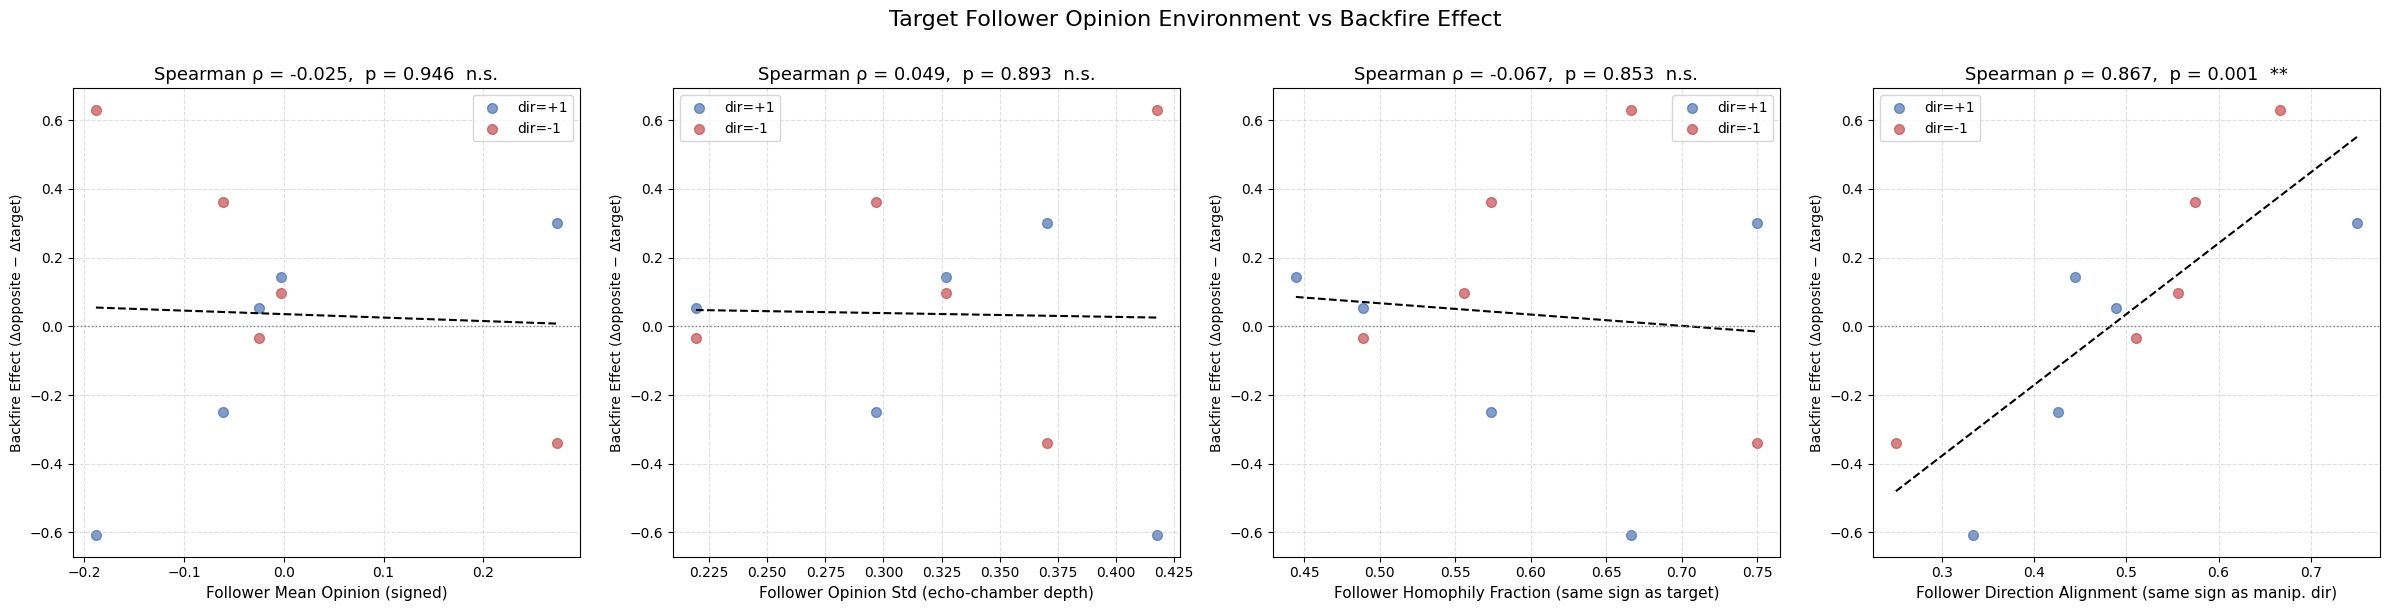

Figure saved to results/summary/homophily_backfire.png

follower_dir_alignment ~ backfire: per-direction Spearman
  dir=-1  N=5  rho=+1.000  p=0.0000
  dir=+1  N=5  rho=+0.900  p=0.0374


In [56]:
HOMOPHILY_METRICS = [
    ('follower_mean_opinion',   'Follower Mean Opinion (signed)'),
    ('follower_opinion_std',    'Follower Opinion Std (echo-chamber depth)'),
    ('follower_homophily_frac', 'Follower Homophily Fraction (same sign as target)'),
    ('follower_dir_alignment',  'Follower Direction Alignment (same sign as manip. dir)'),
]

df_plot = df.dropna(subset=['backfire_effect'])
colors   = {1.0: '#4c72b0', -1.0: '#c44e52'}

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (metric, xlabel) in zip(axes, HOMOPHILY_METRICS):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['backfire_effect'].values

    for sign, c in colors.items():
        mask = sub['target_sign'] == sign
        ax.scatter(sub.loc[mask, metric], sub.loc[mask, 'backfire_effect'],
                   color=c, alpha=0.7, s=50, label=f'dir={sign:+.0f}')

    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Backfire Effect (Δopposite − Δtarget)', fontsize=10)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Target Follower Opinion Environment vs Backfire Effect", fontsize=16, y=1.01)
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, "summary", "homophily_backfire.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/homophily_backfire.png")

# ---------- per-direction breakdown for dir_alignment ----------
print("\nfollower_dir_alignment ~ backfire: per-direction Spearman")
for sign in [-1.0, 1.0]:
    sub = df_plot[df_plot['target_sign'] == sign].dropna(subset=['follower_dir_alignment'])
    rho, p = stats.spearmanr(sub['follower_dir_alignment'], sub['backfire_effect'])
    print(f"  dir={sign:+.0f}  N={len(sub)}  rho={rho:+.3f}  p={p:.4f}")

## Directional Robustness: Seeds Where Both Directions Backfire

We classify each seed by whether backfire occurs in *both*, *one*, or *neither* manipulation direction.

**"Both-direction backfire" is theoretically the cleanest signal**: it is invariant to the direction-of-manipulation confound. A target that generates counter-mobilisation regardless of which way it is pushed must possess some structural property that guarantees the reaction — independent of the opinion asymmetry in the broader network.

We compare structural metrics between the **both** group and the **rest** using Mann-Whitney U (distribution-free) and the rank-biserial correlation *r* as effect size.

In [57]:
# ---------------------------------------------------------------------------
# Classify seeds by backfire robustness
# ---------------------------------------------------------------------------
paired = {}
for _, row in df.iterrows():
    seed = row['seed']
    if seed not in paired:
        paired[seed] = {}
    paired[seed][row['target_sign']] = row

def classify_seed(d):
    if -1.0 not in d or 1.0 not in d:
        return None
    b_neg = d[-1.0]['backfire_effect']
    b_pos = d[1.0]['backfire_effect']
    if b_neg > 0 and b_pos > 0:
        return 'both'
    elif b_neg <= 0 and b_pos <= 0:
        return 'neither'
    else:
        return 'one'

seed_class = {s: classify_seed(d) for s, d in paired.items() if classify_seed(d) is not None}
print("Seed classification:")
for label in ['both', 'one', 'neither']:
    seeds = [s for s, c in seed_class.items() if c == label]
    print(f"  {label:8s}: {len(seeds)} seeds")

# Build seed-level summary frame (structural metrics same for both dirs, use dir=-1 row)
def make_seed_row(seed, d):
    base = dict(d[-1.0])
    base['backfire_neg']  = d[-1.0]['backfire_effect']
    base['backfire_pos']  = d[1.0]['backfire_effect']
    base['mean_backfire'] = (d[-1.0]['backfire_effect'] + d[1.0]['backfire_effect']) / 2
    base['backfire_class'] = seed_class[seed]
    return base

df_seeds = pd.DataFrame([make_seed_row(s, paired[s])
                         for s in seed_class if seed_class[s] is not None])
print(f"\nSeed-level frame: {len(df_seeds)} rows")
print(df_seeds.groupby('backfire_class')['in_degree'].describe()[['count', '50%', 'mean', 'std']])

Seed classification:
  both    : 1 seeds
  one     : 4 seeds
  neither : 0 seeds

Seed-level frame: 5 rows
                count    50%    mean        std
backfire_class                                 
both              1.0   63.0   63.00        NaN
one               4.0  128.0  129.25  31.637267


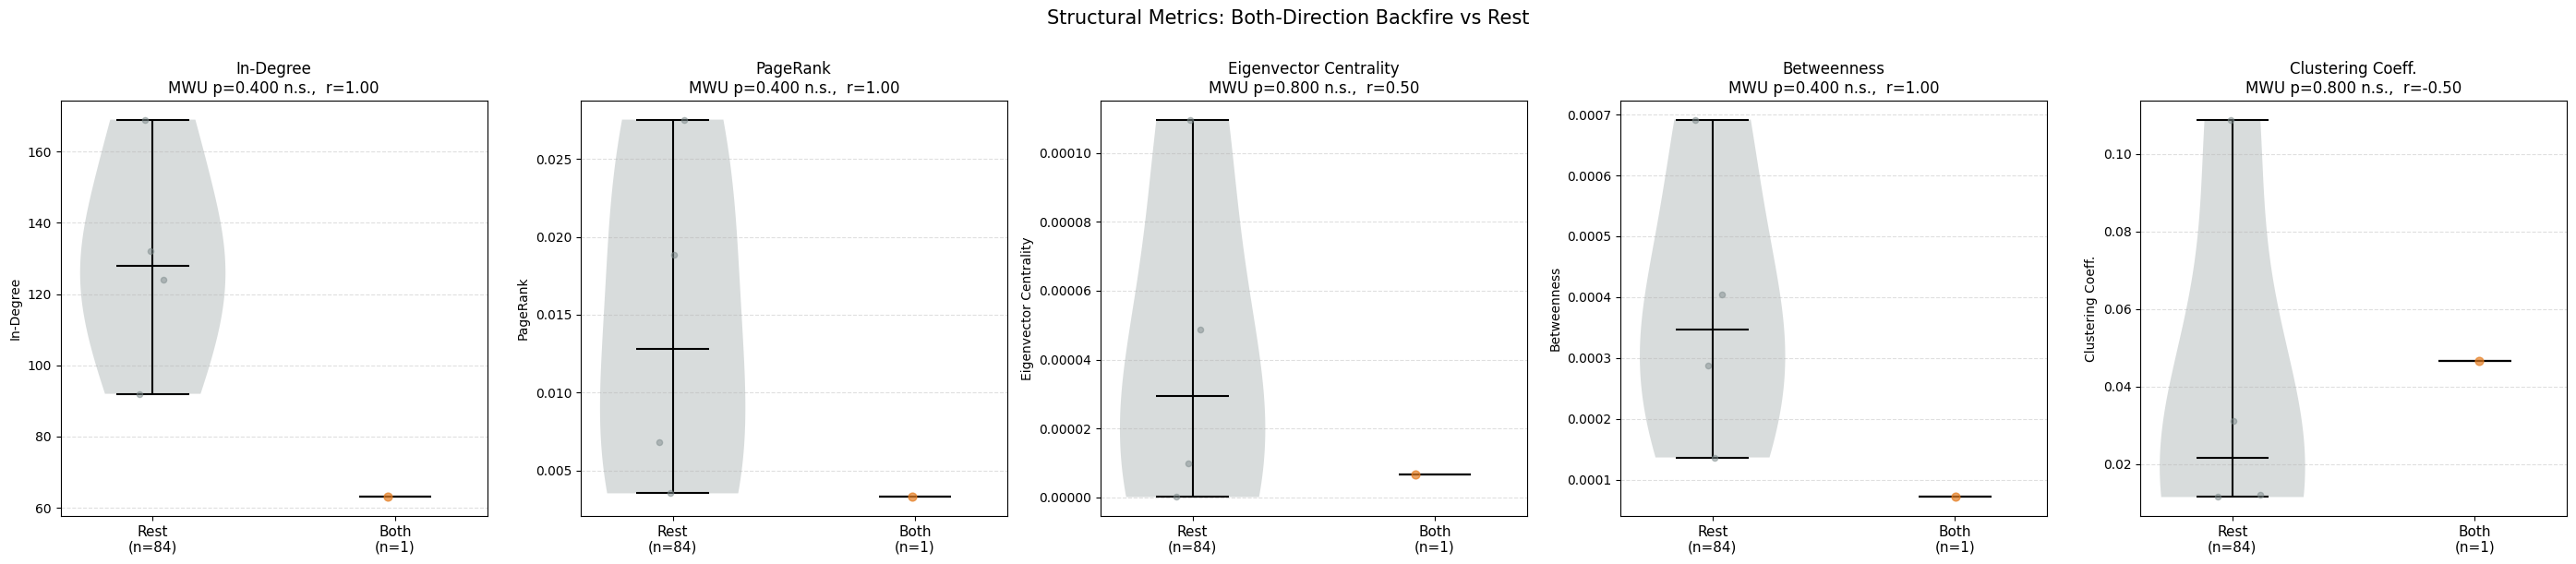

Saved: results/summary/both_backfire_structure.png


In [58]:
# ---------------------------------------------------------------------------
# Fig 1: Structural metric distributions — both vs rest (violin + strip)
# ---------------------------------------------------------------------------
from scipy import stats as sp_stats

both_df = df_seeds[df_seeds['backfire_class'] == 'both']
rest_df = df_seeds[df_seeds['backfire_class'] != 'both']

METRICS_COMPARE = [
    ('in_degree',   'In-Degree'),
    ('pagerank',    'PageRank'),
    ('eigenvector', 'Eigenvector Centrality'),
    ('betweenness', 'Betweenness'),
    ('clustering',  'Clustering Coeff.'),
]

fig, axes = plt.subplots(1, 5, figsize=(28, 6))
palette = {'both': '#e67e22', 'rest': '#7f8c8d'}

for ax, (metric, label) in zip(axes, METRICS_COMPARE):
    a = both_df[metric].dropna().values
    b = rest_df[metric].dropna().values

    # violin
    parts = ax.violinplot([b, a], positions=[0, 1], showmedians=True, widths=0.6)
    parts['bodies'][0].set_facecolor(palette['rest'])
    parts['bodies'][1].set_facecolor(palette['both'])
    for p in ['cmedians','cbars','cmins','cmaxes']:
        parts[p].set_color('black')

    # strip jitter
    ax.scatter(np.random.normal(0, 0.05, len(b)), b,
               color=palette['rest'], alpha=0.5, s=20, zorder=3)
    ax.scatter(np.random.normal(1, 0.05, len(a)), a,
               color=palette['both'], alpha=0.7, s=40, zorder=3)

    U, p = sp_stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - 2*U / (len(a) * len(b))
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    ax.set_title(f'{label}\nMWU p={p:.3f} {sig},  r={r:.2f}', fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Rest\n(n=84)', f'Both\n(n={len(a)})'], fontsize=11)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Structural Metrics: Both-Direction Backfire vs Rest', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "both_backfire_structure.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/both_backfire_structure.png")

/tmp/ipykernel_223231/3844544512.py:13: RuntimeWarning: invalid value encountered in scalar divide
  or_ = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
/home/tomoyatakeda/document/research/manipulation-backfire-model/venv/lib/python3.11/site-packages/scipy/stats/_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/tomoyatakeda/document/research/manipulation-backfire-model/venv/lib/python3.11/site-packages/scipy/stats/_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/tomoyatakeda/document/research/manipulation-backfire-model/venv/lib/python3.11/site-packages/scipy/stats/_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


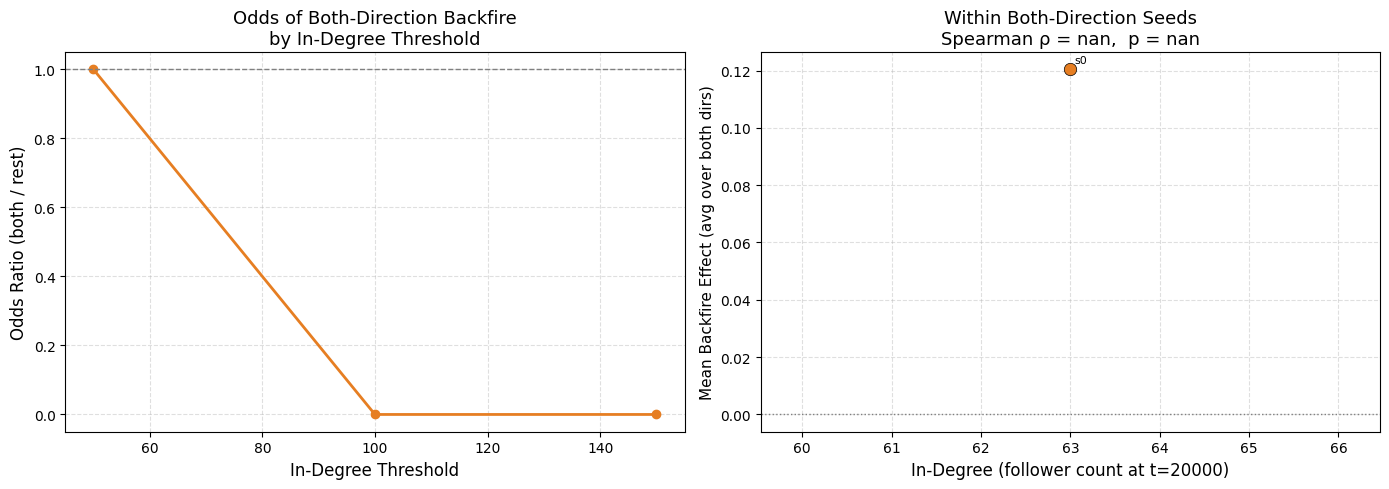

Saved: results/summary/both_backfire_threshold.png

In-degree threshold — fraction above threshold & odds ratio
 threshold  both_frac  rest_frac         OR
       100      0.000      0.750       0.00
       200      0.000      0.000        nan
       300      0.000      0.000        nan
       400      0.000      0.000        nan
       500      0.000      0.000        nan


/tmp/ipykernel_223231/3844544512.py:56: RuntimeWarning: invalid value encountered in scalar divide
  OR = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))


In [59]:
# ---------------------------------------------------------------------------
# Fig 2: In-degree threshold odds-ratio curve + within-both scatter
# ---------------------------------------------------------------------------
fig, (ax_or, ax_sc) = plt.subplots(1, 2, figsize=(14, 5))

# -- Odds-ratio curve --
thresholds = list(range(50, 850, 50))
ors = []
for t in thresholds:
    f_b = (both_df['in_degree'] >= t).mean()
    f_r = (rest_df['in_degree'] >= t).mean()
    eps = 1e-9
    or_ = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
    ors.append(or_)

ax_or.plot(thresholds, ors, 'o-', color='#e67e22', linewidth=2)
ax_or.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax_or.set_xlabel('In-Degree Threshold', fontsize=12)
ax_or.set_ylabel('Odds Ratio (both / rest)', fontsize=12)
ax_or.set_title('Odds of Both-Direction Backfire\nby In-Degree Threshold', fontsize=13)
ax_or.grid(True, linestyle='--', alpha=0.4)

# -- Scatter: within both-backfire, in_degree vs mean_backfire --
rho, p = sp_stats.spearmanr(both_df['in_degree'], both_df['mean_backfire'])
ax_sc.scatter(both_df['in_degree'], both_df['mean_backfire'],
              color='#e67e22', s=80, zorder=3, edgecolors='k', linewidths=0.5)

# label each seed
for _, row in both_df.iterrows():
    ax_sc.annotate(f"s{int(row['seed'])}", (row['in_degree'], row['mean_backfire']),
                   fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                   textcoords='offset points')

slope, intercept, *_ = sp_stats.linregress(both_df['in_degree'].values,
                                            both_df['mean_backfire'].values)
x_line = np.linspace(both_df['in_degree'].min(), both_df['in_degree'].max(), 200)
ax_sc.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)
ax_sc.axhline(0, color='gray', linestyle=':', linewidth=1)
ax_sc.set_xlabel('In-Degree (follower count at t=20000)', fontsize=12)
ax_sc.set_ylabel('Mean Backfire Effect (avg over both dirs)', fontsize=11)
ax_sc.set_title(f'Within Both-Direction Seeds\nSpearman ρ = {rho:.3f},  p = {p:.4f}', fontsize=13)
ax_sc.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "both_backfire_threshold.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/both_backfire_threshold.png")

# In-degree threshold table
print("\nIn-degree threshold — fraction above threshold & odds ratio")
print(f"{'threshold':>10} {'both_frac':>10} {'rest_frac':>10} {'OR':>10}")
for t in [100, 200, 300, 400, 500]:
    f_b = (both_df['in_degree'] >= t).mean()
    f_r = (rest_df['in_degree'] >= t).mean()
    eps = 1e-9
    OR = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
    print(f"{t:>10} {f_b:>10.3f} {f_r:>10.3f} {OR:>10.2f}")

In [60]:
# ---------------------------------------------------------------------------
# Optional: save the per-run metrics table for further analysis
# ---------------------------------------------------------------------------
out_path = os.path.join(RESULTS_DIR, "summary", "structural_backfire_table.csv")
df.to_csv(out_path, index=False)
print(f"Per-run table saved to {out_path}")
df

Per-run table saved to ./results/summary/structural_backfire_table.csv


,run_id,seed,target_sign,target_id,backfire_effect,in_degree,betweenness,clustering,pagerank,eigenvector,target_opinion,follower_mean_opinion,follower_opinion_std,follower_homophily_frac,follower_dir_alignment
0,run_0_dir_-1.0,0,-1.0,10,0.097969,63,0.000072,0.046620,0.003293,6.726620e-06,-0.010682,-0.002737,0.327089,0.555556,0.555556
1,run_0_dir_1.0,0,1.0,10,0.142811,63,0.000072,0.046620,0.003293,6.726620e-06,0.009318,-0.002737,0.327089,0.444444,0.444444
2,run_1_dir_-1.0,1,-1.0,10,0.631051,132,0.000405,0.011447,0.018829,4.875941e-05,-0.190800,-0.188141,0.417695,0.666667,0.666667
3,run_1_dir_1.0,1,1.0,10,-0.608861,132,0.000405,0.011447,0.018829,4.875941e-05,-0.190800,-0.188141,0.417695,0.666667,0.333333
4,run_2_dir_-1.0,2,-1.0,5,-0.340211,124,0.000692,0.011937,0.027525,1.097018e-04,0.072736,0.273866,0.370507,0.750000,0.250000
5,run_2_dir_1.0,2,1.0,5,0.299699,124,0.000692,0.011937,0.027525,1.097018e-04,0.072736,0.273866,0.370507,0.750000,0.750000
6,run_3_dir_-1.0,3,-1.0,43,-0.034129,92,0.000137,0.108844,0.003532,6.170002e-08,0.015918,-0.024481,0.219309,0.489130,0.510870
7,run_3_dir_1.0,3,1.0,43,0.053384,92,0.000137,0.108844,0.003532,6.170002e-08,0.015918,-0.024481,0.219309,0.489130,0.489130
8,run_4_dir_-1.0,4,-1.0,9,0.363239,169,0.000288,0.031053,0.006821,9.957308e-06,-0.182531,-0.060695,0.296792,0.573964,0.573964
9,run_4_dir_1.0,4,1.0,9,-0.248121,169,0.000288,0.031053,0.006821,9.957308e-06,-0.182531,-0.060695,0.296792,0.573964,0.426036
